# 4. Optuna tuning

Use `OptunaSearch` with native Study and Trial objects to compare eight SA
configurations by mean validation cross-entropy, then refit and evaluate once on
test data. This small budget demonstrates selection without establishing optimal
settings.

Generate 400 binary classification examples with six features. Use data/split seed
42, a stratified 60/20/20 train/validation/test split, training-only scaling, and a
6 → 8 → 2 tanh model. Each fit uses 160 SA calls including initialization, minimum
temperature 0.001, float32 CPU, and one Torch thread. Every trial averages seeds
11, 22, and 33, pairing initializations across configurations. The sampler uses
seed 42 and runs serially; the final refit uses independent seed 44.

In [1]:
import hashlib
import importlib.metadata
import platform
from pathlib import Path
from time import perf_counter

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn

import pyperch
from pyperch.plotting import plot_training_curve, prepare_training_curve

torch.set_num_threads(1)
torch.use_deterministic_algorithms(True)
started = perf_counter()
print("Python", platform.python_version(), "|", platform.system(), platform.machine())
print(
    {
        p: importlib.metadata.version(p)
        for p in ["torch", "numpy", "matplotlib", "scikit-learn", "optuna"]
    }
)
optimizer_dir = Path(pyperch.__file__).parent / "optim"
print(
    "Optimizer SHA256:",
    {
        p.name: hashlib.sha256(p.read_bytes()).hexdigest()[:12]
        for p in sorted(optimizer_dir.glob("*.py"))
    },
)

Python 3.12.13 | Darwin arm64
{'torch': '2.12.0', 'numpy': '2.2.6', 'matplotlib': '3.10.9', 'scikit-learn': '1.7.2', 'optuna': '4.8.0'}
Optimizer SHA256: {'__init__.py': '689555afdfc1', 'base.py': '99736e2f4cd2', 'ga.py': '2efcfab3ac45', 'rhc.py': '47cda7de86b1', 'sa.py': '8ca21675749b'}


## Search setup

Search `step_size` log-uniformly from 0.01 to 0.2, `temperature` log-uniformly from
0.005 to 0.1, and `cooling` uniformly from 0.95 to 0.995. Each fit restores its
best training-loss parameters before validation. Trials record individual seed
losses and measured objective counts. Test data stay unused during selection.
With TPE's default startup behavior, all eight trials are random startup samples.

In [2]:
import optuna
from IPython.display import Markdown, display
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from pyperch.optim import SA
from pyperch.search import OptunaSearch

optuna.logging.set_verbosity(optuna.logging.WARNING)
X, y = make_classification(
    n_samples=400,
    n_features=6,
    n_informative=4,
    n_redundant=0,
    class_sep=1.2,
    random_state=42,
)
Xt, Xreserved, yt, yreserved = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=42
)
Xv, Xtest, yv, ytest = train_test_split(
    Xreserved, yreserved, test_size=0.5, stratify=yreserved, random_state=42
)
scaler = StandardScaler().fit(Xt)
Xt, Xv, Xtest = [
    torch.tensor(scaler.transform(a), dtype=torch.float32) for a in (Xt, Xv, Xtest)
]
yt, yv, ytest = [torch.tensor(a, dtype=torch.long) for a in (yt, yv, ytest)]
loss_fn = nn.CrossEntropyLoss()
SEEDS = [11, 22, 33]
CALLS = 160


def train(params, seed, record=False):
    torch.manual_seed(seed)
    model = nn.Sequential(nn.Linear(6, 8), nn.Tanh(), nn.Linear(8, 2))
    optimizer = SA(
        model.parameters(), **params, min_temperature=0.001, random_state=seed
    )
    history = {"Train": [], "Validation": []}

    @torch.no_grad()
    def closure():
        return loss_fn(model(Xt), yt)

    for _iteration in range(CALLS):
        optimizer.step(closure)
        if record:
            with torch.no_grad():
                history["Train"].append(loss_fn(model(Xt), yt).item())
                history["Validation"].append(loss_fn(model(Xv), yv).item())
    optimizer.restore_best()
    with torch.no_grad():
        valid_loss = loss_fn(model(Xv), yv).item()
    return model, valid_loss, optimizer.function_evals, history


search = OptunaSearch(
    param_space={
        "step_size": ("float", 0.01, 0.2, True),
        "temperature": ("float", 0.005, 0.1, True),
        "cooling": ("float", 0.95, 0.995),
    },
    direction="minimize",
    study_kwargs={
        "sampler": optuna.samplers.TPESampler(seed=42),
        "study_name": "sa_teaching",
    },
)


def objective(params, trial):
    losses, counts = [], []
    for seed in SEEDS:
        _, valid_loss, count, _ = train(params, seed)
        losses.append(valid_loss)
        counts.append(count)
    trial.set_user_attr("seeds", SEEDS)
    trial.set_user_attr("validation_losses", losses)
    trial.set_user_attr("objective_calls", counts)
    return float(np.mean(losses))


study = search.search(objective, n_trials=8, n_jobs=1)

rows = [
    "| Trial | State | Mean loss | Seed losses (11, 22, 33) |",
    "| --- | --- | --- | --- |",
]
for trial in study.trials:
    losses = ", ".join(
        f"{v:.4f}" for v in trial.user_attrs.get("validation_losses", [])
    )
    value = "n/a" if trial.value is None else f"{trial.value:.4f}"
    rows.append(f"| {trial.number} | {trial.state.name} | {value} | {losses} |")
display(Markdown("\n".join(rows)))
print("Objective calls per trial seed: 160; restored validation passes per seed: 1")
print(
    "Selected trial:",
    study.best_trial.number,
    "mean validation loss:",
    round(study.best_value, 4),
)
for name, distribution in study.best_trial.distributions.items():
    print(name, distribution)
for trial in study.trials:
    print(
        f"Trial {trial.number}: "
        + ", ".join(f"{k}={v:.6f}" for k, v in trial.params.items())
    )

| Trial | State | Mean loss | Seed losses (11, 22, 33) |
| --- | --- | --- | --- |
| 0 | COMPLETE | 0.6858 | 0.6460, 0.7520, 0.6595 |
| 1 | COMPLETE | 0.6102 | 0.5994, 0.6285, 0.6027 |
| 2 | COMPLETE | 0.6984 | 0.6758, 0.7564, 0.6628 |
| 3 | COMPLETE | 0.5825 | 0.5258, 0.6038, 0.6178 |
| 4 | COMPLETE | 0.5549 | 0.5233, 0.5762, 0.5652 |
| 5 | COMPLETE | 0.6797 | 0.6478, 0.7408, 0.6504 |
| 6 | COMPLETE | 0.6441 | 0.6074, 0.6965, 0.6284 |
| 7 | COMPLETE | 0.6819 | 0.6518, 0.7423, 0.6516 |

Objective calls per trial seed: 160; restored validation passes per seed: 1
Selected trial: 4 mean validation loss: 0.5549
step_size FloatDistribution(high=0.2, log=True, low=0.01, step=None)
temperature FloatDistribution(high=0.1, log=True, low=0.005, step=None)
cooling FloatDistribution(high=0.995, log=False, low=0.95, step=None)
Trial 0: step_size=0.030711, temperature=0.086274, cooling=0.982940
Trial 1: step_size=0.060100, temperature=0.007979, cooling=0.957020
Trial 2: step_size=0.011901, temperature=0.066972, cooling=0.977050
Trial 3: step_size=0.083411, temperature=0.005318, cooling=0.993646
Trial 4: step_size=0.121069, temperature=0.009446, cooling=0.958182
Trial 5: step_size=0.017323, temperature=0.012439, cooling=0.973614
Trial 6: step_size=0.036473, temperature=0.011964, cooling=0.977533
Trial 7: step_size=0.015187, temperature=0.011997, cooling=0.966486


## Search history

Each dot is a trial's mean validation loss; the best-value trace shows cumulative
selection progress. Trial number is neither a training iteration nor a sample
count. Individual seed losses and trial states appear in the table above.

The [Optuna Matplotlib history API](https://optuna.readthedocs.io/en/stable/reference/visualization/matplotlib/generated/optuna.visualization.matplotlib.optimization_history.html)
provides this plot. The cell displays its experimental-API warning and uses
`rc_context` to contain its style changes.

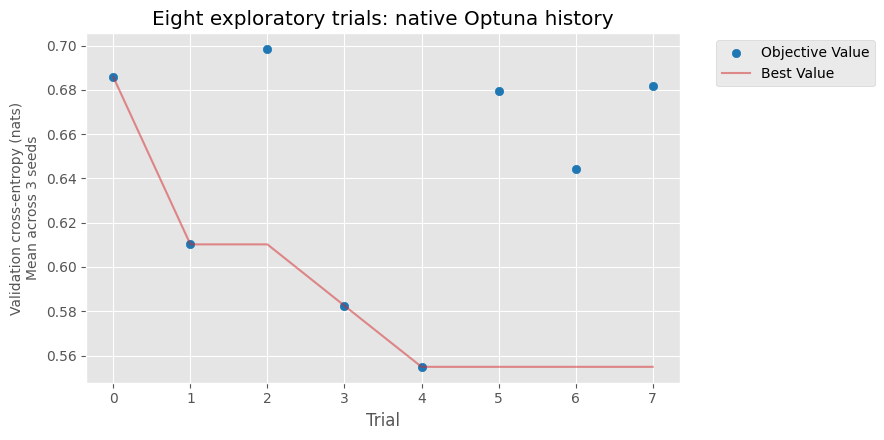

In [3]:
import warnings

from optuna.visualization.matplotlib import plot_optimization_history

with plt.rc_context():
    with warnings.catch_warnings(record=True) as plot_warnings:
        warnings.simplefilter("always", optuna.exceptions.ExperimentalWarning)
        ax = plot_optimization_history(study)
    ax.set_ylabel("Validation cross-entropy (nats)\nMean across 3 seeds", fontsize=10)
    ax.set_title("Eight exploratory trials: native Optuna history")
    ax.figure.set_size_inches(9, 4.5)
    ax.figure.tight_layout()
    plt.show()
for warning in plot_warnings:
    print(f"{warning.category.__name__}: {warning.message}")

## Refit and evaluate

A Study stores parameters and values, not model weights. Refit the selected
configuration with seed 44, the same budget, and the original training split.
Record current-model losses, restore the best training checkpoint, then score
test data once. The curve ends at the current model before restoration, so its
endpoint can differ from the restored checkpoint's loss. This single refit has no
uncertainty band.

In [4]:
final_model, final_valid_loss, objective_calls, history = train(
    study.best_params, 44, record=True
)
with torch.no_grad():
    test_logits = final_model(Xtest)
    test_loss = loss_fn(test_logits, ytest).item()
    test_accuracy = (test_logits.argmax(1) == ytest).float().mean().item()
print("Final refit seed: 44; objective calls:", objective_calls)
print(
    "Monitoring forwards:",
    2 * CALLS,
    "; restored validation forwards: 1; test forwards: 1",
)
print(f"Restored validation cross-entropy: {final_valid_loss:.4f}")
print(f"Untouched test cross-entropy: {test_loss:.4f}; accuracy: {test_accuracy:.3f}")

Final refit seed: 44; objective calls: 160
Monitoring forwards: 320 ; restored validation forwards: 1; test forwards: 1
Restored validation cross-entropy: 0.5873
Untouched test cross-entropy: 0.5458; accuracy: 0.738


This training curve shows cross-entropy versus SA calls during the refit. Look for
validation improvement alongside falling training loss. The independent seed means
its validation loss need not match the search trial's three-seed mean.

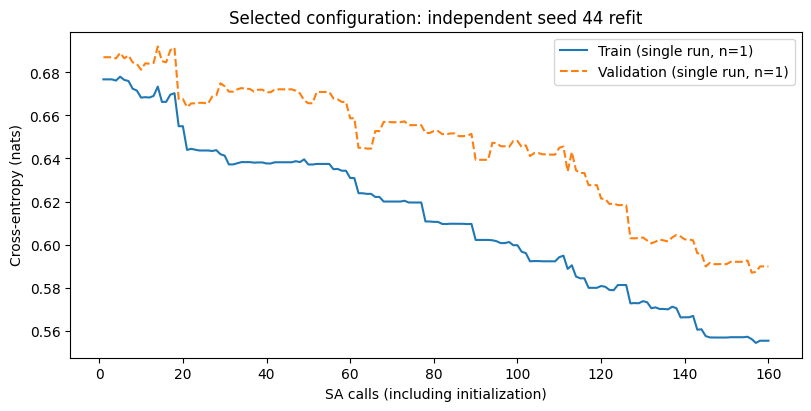

In [5]:
curve = prepare_training_curve(
    np.arange(1, CALLS + 1),
    history,
    metric="Cross-entropy (nats)",
    x_label="SA calls (including initialization)",
)
fig, ax = plt.subplots(figsize=(8, 4), layout="constrained")
plot_training_curve(curve, ax=ax)
ax.set_title("Selected configuration: independent seed 44 refit")
plt.show()

See the [search guide](../../docs/search.md),
[plotting reference](../../docs/plotting.md), and [notebook setup](../README.md).

In [6]:
print(f"Notebook computation and plotting: {perf_counter() - started:.2f} seconds")

Notebook computation and plotting: 0.83 seconds
